In [1084]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1085]:
data_path = "../data/"

df_c = pd.read_csv(data_path + "claims.csv")
df_cp = pd.read_csv(data_path + "claim_payments.csv")
df_ibf = pd.read_csv(data_path + "industry_benchmark_factors.csv")
df_ibf = pd.pivot(df_ibf, index="claim_type", columns="developmental_period", values="industry_df")
df_ibf = pd.concat([df_ibf.iloc[:,2:], df_ibf.iloc[:,0:2]], axis=1).fillna(1)

In [1118]:
# Join df_c and df_cp together on claim_id
df = df_c.merge(df_cp, on='claim_id', how='left')

### Ultimate Loss Calculator

Cumulative paid claims loss development triangle:

In [ ]:
# Define a helper function producing a pivot table of payments by payment year and accident year
def aggregate_payments(ctype: str) -> pd.DataFrame:
    # Check if input is correct
    if ctype not in df_c['claim_type'].unique().tolist():
        raise Exception(f'You need to input a claim type (as a string) from: {df_c['claim_type'].unique().tolist()}')

    # Create the aggregate payments data frame by payment year and accident year
    df_ap = pd.pivot_table(df[df['claim_type'] == ctype].fillna(0), 
                            values="payment_amount",
                            index="claim_id", 
                            columns="payment_year", 
                            aggfunc="sum")
    df_ap = df_ap.fillna(0)
    df_ap['total_claim_payment'] = df_ap.sum(axis=1)
    df_ap = df_ap.merge(df_c[['claim_id', 'accident_year']], 
                        on="claim_id", 
                        how="left")

    return df_ap


In [769]:
# Define a function showing the LDT for a certain claim type.
def ldt(ctype: str) -> pd.DataFrame : 
    # Check if input is correct
    if ctype not in df_c['claim_type'].unique().tolist():
        raise Exception(f'You need to input a claim type (as a string) from: {df_c['claim_type'].unique().tolist()}')

    # Create the aggregate payments data frame by payment year and accident year
    df_ap = aggregate_payments(ctype)
    
    # Create the index and the columns of the LDT
    ind = range(2018, 2026)
    cols = pd.Index([(f'{12*i}→{12*(i+1)}') for i in range(8)], name='developmental_period')

    # Create the LDT
    ldt = []
    for j in range(8):
        l = []
        for i in range(8 - j):
            pt = df_ap[(df_ap['accident_year'] == 2018 + j) & (df_ap['total_claim_payment'] < 250000)]
            val = pt[range(2018 + j,2018 + i + j + 1)].to_numpy().sum()
            l.append(np.round(val, 2))
        if len(l) < 8:
            l += [np.nan for _ in range(8 - len(l))]
        ldt.append(l)

    ldt = pd.DataFrame(np.array(ldt), columns=cols, index=ind)
    ldt.index.name = "accident year"
    return ldt.apply(pd.to_numeric, errors="coerce")

In [770]:
df_ldt = ldt('Theft')
df_ldt

developmental_period,0→12,12→24,24→36,36→48,48→60,60→72,72→84,84→96
accident year,,,,,,,,
2018,23391.83,28596.65,28596.65,28596.65,28596.65,28596.65,28596.65,28596.65
2019,32543.59,34181.91,34181.91,34181.91,34181.91,34181.91,34181.91,NaN
2020,17455.41,17455.41,17455.41,17455.41,17455.41,17455.41,NaN,NaN
2021,19859.90,19859.90,19859.90,19859.90,19859.90,NaN,NaN,NaN
2022,58236.97,59778.55,59778.55,59778.55,NaN,NaN,NaN,NaN
2023,44122.50,66716.04,66716.04,NaN,NaN,NaN,NaN,NaN
2024,19432.15,19432.15,NaN,NaN,NaN,NaN,NaN,NaN
2025,19813.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Average loss developmental factors:

In [790]:
def average_ldfs(ldt: pd.DataFrame, n: int) -> pd.DataFrame:
    '''
        ldt: Loss development triangle (as a DataFrame object)
        n: the number of additonal columns to append
    '''
    if n < 0:
        raise Exception('n must be a nonnegative integer')
    
    numrows = ldt.shape[0]
    numcols = ldt.shape[1]
    cols = ldt.columns[1:].to_list()
    ldfs = []

    # Compute average of pairwise factors
    for i in range(numrows - 1):
        pair = ldt.iloc[0:numrows - 1 - i, i : i + 2]
        pair['factor'] = pair.iloc[:, 1] / pair.iloc[:, 0]
        ldfs.append(pair['factor'].mean(numeric_only=True))

    # Pad extra columns if needed
    if n == 0:
        cols[-1] = (cols[-1][0 : cols[-1].find('→') + 1] + 'Ult')
    if n > 0:
        cols += [(f'{12 * (numcols + i)}→{12 * (numcols + i + 1)}') for i in range(n)]
        cols[-1] = cols[-1][0 : cols[-1].find('→') + 1] + 'Ult'
        ldfs += [ float(1) for _ in range(n)]
    cols = pd.Index(cols, name="developmental_period")
    
    return pd.DataFrame([ldfs], columns=cols)

In [792]:
average_ldfs_list = []
for claim_type in df_c['claim_type'].unique().tolist():
    avg_ldfs = average_ldfs(ldt(claim_type), 3)
    avg_ldfs.index = [claim_type]
    avg_ldfs.index.name = 'claim_type'
    average_ldfs_list.append(avg_ldfs)
df_avg_ldfs = pd.concat(average_ldfs_list, axis=0)
df_avg_ldfs

developmental_period,12→24,24→36,36→48,48→60,60→72,72→84,84→96,96→108,108→120,120→Ult
claim_type,,,,,,,,,,
Wind/Hail,1.160758,1.000000,1.00000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Water Damage,1.640712,1.004057,1.00000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Fire,2.775173,1.188071,1.00137,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Flood,2.617605,1.041029,1.00000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Theft,1.115912,1.000000,1.00000,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Credibility factor:

In [766]:
def credf(ctype: str) -> float: 
    # Check if input is correct
    if ctype not in df_c['claim_type'].unique().tolist():
        raise Exception(f'You need to input a claim type (as a string) from: {df_c['claim_type'].unique().tolist()}')

    df_ap = aggregate_payments(ctype)

    return df_ap[ df_ap['total_claim_payment'] < 250000 ].shape[0] / 1082.0

In [811]:
credf_list = []
for claim_type in df_c['claim_type'].unique().tolist():
    df_credf = pd.DataFrame([[credf(claim_type)]], 
                            columns=['cred_factor'], 
                            index=pd.Index([claim_type], name='claim_type'))
    credf_list.append(df_credf)
df_credf = pd.concat(credf_list, axis=0)
df_credf


,cred_factor
claim_type,
Wind/Hail,0.102588
Water Damage,0.142329
Fire,0.100739
Flood,0.041590
Theft,0.071165


Industry benchmark factors:

In [784]:
df_ibf

developmental_period,12→24,24→36,36→48,48→60,60→72,72→84,84→96,96→108,108→120,120→Ult
claim_type,,,,,,,,,,
Fire,2.862,1.418,1.182,1.092,1.048,1.026,1.014,1.008,1.004,1.003
Flood,2.385,1.298,1.128,1.058,1.028,1.012,1.005,1.000,1.000,1.000
Theft,1.192,1.024,1.006,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Water Damage,1.895,1.172,1.058,1.022,1.008,1.000,1.000,1.000,1.000,1.000
Wind/Hail,1.635,1.112,1.038,1.010,1.000,1.000,1.000,1.000,1.000,1.000


Selected final development factors:

(Here, the selected development factor is the average of the corresponding loss development factor and industry benchmark factor weighted by the credibility factor.)

In [870]:
df_zeros = pd.DataFrame(0.0, index=df_avg_ldfs.index, columns=df_avg_ldfs.columns)

df_final_df = df_zeros.copy()

for i in range(df_avg_ldfs.shape[1]):
    # Isolate each calculation of final development factors
    # by column via entry-by-entry operations (which can be 
    # only done using data frames with the same dimensions)
    df_ind = df_zeros.copy()
    df_credf_ind = df_zeros.copy()
    df_ind.iloc[:,i] = 1
    df_credf_ind.iloc[:,i]= df_credf.iloc[:,0]      
    df_final_df += df_credf_ind * df_avg_ldfs + (1 - df_credf_ind) * df_ind * df_ibf
    
df_final_df

developmental_period,12→24,24→36,36→48,48→60,60→72,72→84,84→96,96→108,108→120,120→Ult
claim_type,,,,,,,,,,
Wind/Hail,1.586349,1.100510,1.034102,1.008974,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Water Damage,1.858807,1.148097,1.049745,1.018869,1.006861,1.000000,1.000000,1.000000,1.000000,1.000000
Fire,2.853253,1.394837,1.163803,1.082732,1.043165,1.023381,1.012590,1.007194,1.003597,1.002698
Flood,2.394674,1.287313,1.122677,1.055588,1.026835,1.011501,1.004792,1.000000,1.000000,1.000000
Theft,1.186585,1.022292,1.005573,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Final ultimate development factors:

In [933]:
df_final_ult_df = df_final_df.copy()
cols = df_final_ult_df.columns.to_list()
numcols = df_final_ult_df.shape[1]

for i in range(numcols):
    cols[i] = cols[i][0 : cols[i].find('→') + 1] + 'Ult'
df_final_ult_df.columns = pd.Index(cols, name='developmental_period')

for i in range(1, numcols):
    df_final_ult_df.iloc[:, numcols - 1 - i] = df_final_ult_df.iloc[:, numcols - 1 - i] * df_final_ult_df.iloc[:, numcols - i]
df_final_ult_df

developmental_period,12→Ult,24→Ult,36→Ult,48→Ult,60→Ult,72→Ult,84→Ult,96→Ult,108→Ult,120→Ult
claim_type,,,,,,,,,,
Wind/Hail,1.821528,1.148252,1.043382,1.008974,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Water Damage,2.298183,1.236375,1.076891,1.025860,1.006861,1.000000,1.000000,1.000000,1.000000,1.000000
Fire,5.494529,1.925707,1.380596,1.186280,1.095636,1.050300,1.026304,1.013544,1.006305,1.002698
Flood,3.812614,1.592122,1.236780,1.101635,1.043622,1.016348,1.004792,1.000000,1.000000,1.000000
Theft,1.219797,1.027989,1.005573,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Ultimate losses:

In [880]:
# Define a helper function producing a pivot table of payments by payment year and accident year
def aggregate_open_payments(ctype: str) -> pd.DataFrame:
    # Check if input is correct
    if ctype not in df_c['claim_type'].unique().tolist():
        raise Exception(f'You need to input a claim type (as a string) from: {df_c['claim_type'].unique().tolist()}')

    # Create the aggregate payments data frame by payment year and accident year
    df_ap = pd.pivot_table(df[(df['claim_type'] == ctype) & (df['status'] == 'Open')].fillna(0), 
                            values="payment_amount",index="claim_id", 
                            columns="payment_year", 
                            aggfunc="sum")
    df_ap = df_ap.fillna(0)
    df_ap['total_claim_payment'] = df_ap.sum(axis=1)
    df_ap = df_ap.merge(df_c[['claim_id', 'accident_year']], 
                        on="claim_id", 
                        how="left")

    return df_ap


In [930]:
df_aop = pd.DataFrame(0, columns=pd.Index(range(2018, 2026), name='accident_year'), index=pd.Index(['base'], name='claim_type'))

for claim_type in df_c['claim_type'].unique().tolist():
    df_aop_ct = aggregate_open_payments(claim_type)
    df_pt_aop = pd.pivot_table(df_aop_ct[ df_aop_ct['total_claim_payment'] < 250000 ], 
                                columns='accident_year', 
                                values='total_claim_payment',
                                aggfunc='sum')
    df_pt_aop.index = pd.Index([claim_type], name='claim_type')
    df_aop = pd.concat([df_aop, df_pt_aop], axis=0).fillna(0)

df_aop = df_aop.iloc[1:,:]
df_aop

accident_year,2018,2019,2020,2021,2022,2023,2024,2025
claim_type,,,,,,,,
Wind/Hail,0.00,0.0,0.00,0.0,0.00,53110.35,175850.10,41676.38
Water Damage,0.00,0.0,0.00,0.0,0.00,0.00,182005.26,86727.23
Fire,40006.97,0.0,16420.06,44936.6,404580.11,536360.42,149855.94,33167.06
Flood,0.00,0.0,0.00,0.0,93142.83,118045.55,57784.48,19832.70
Theft,0.00,0.0,0.00,0.0,0.00,0.00,2485.08,19813.19


In [947]:
df_final_ult = df_final_ult_df.iloc[:,:-2].iloc[:,::-1]
df_final_ult.columns = pd.Index(range(2018, 2026), name='accident_year')

df_ult = df_aop * df_final_ult
df_ult['total'] = np.round(df_ult.sum(axis=1), 2)
df_ult

accident_year,2018,2019,2020,2021,2022,2023,2024,2025,total
claim_type,,,,,,,,,
Wind/Hail,0.000000,0.0,0.000000,0.000000,0.000000,55414.373541,201920.281460,75914.706464,333249.36
Water Damage,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,225026.756420,199315.057433,424341.81
Fire,40548.823153,0.0,17245.987684,49234.138715,479945.171693,740497.254414,288578.635730,182237.388019,1798287.40
Flood,0.000000,0.0,0.000000,0.000000,102609.397354,145996.340302,91999.952312,75614.420520,416220.11
Theft,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,2554.635646,24168.067982,26722.70


Premium rate change:

In [962]:
df_prc = df_ult[[2025]]
df_prc.columns = pd.Index(['2025_total_ultimate_claims'])
df_prc.insert(0, 
              column='2025_total_premium', 
              value={'Wind/Hail': 97326.55,
                     'Water Damage': 229097.77,
                     'Fire': 249640.26,
                     'Flood': 94518.03,
                     'Theft': 30210.08})
df_prc['current_loss_ratio'] = df_prc['2025_total_ultimate_claims'] / df_prc['2025_total_premium']
df_prc.insert(2, 
              column='target_loss_ratio', 
              value={'Wind/Hail': 0.81,
                     'Water Damage': 0.87,
                     'Fire': 0.72,
                     'Flood': 0.67,
                     'Theft': 0.81})
df_prc['rate_change'] = np.round(df_prc['current_loss_ratio'] / df_prc['target_loss_ratio'] - 1,4)


In [963]:
df_prc

,2025_total_premium,2025_total_ultimate_claims,target_loss_ratio,current_loss_ratio,rate_change
claim_type,,,,,
Wind/Hail,97326.55,75914.706464,0.81,0.78,-0.0370
Water Damage,229097.77,199315.057433,0.87,0.87,-0.0000
Fire,249640.26,182237.388019,0.72,0.73,0.0139
Flood,94518.03,75614.420520,0.67,0.80,0.1940
Theft,30210.08,24168.067982,0.81,0.80,-0.0123


### Aggregate payments analysis

Aggregate claim payments (by accident month)

In [1090]:
df_ap = pd.pivot_table(df.fillna(0), 
                        values="payment_amount",
                        index="claim_id", 
                        columns="payment_year", 
                        aggfunc="sum")
df_ap = df_ap.fillna(0)
df_ap['total_claim_payment'] = df_ap.sum(axis=1)
df_ap = df_ap.merge(df_c[['claim_id', 'accident_month', 'claim_type']], 
                    on="claim_id", 
                    how="left")
df_ap = df_ap[['claim_id', 'total_claim_payment', 'accident_month', 'claim_type']]
df_ap

,claim_id,total_claim_payment,accident_month,claim_type
0,10001,4777.43,5,Wind/Hail
1,10002,6335.58,1,Water Damage
2,10003,4640.37,6,Wind/Hail
3,10004,6517.61,12,Wind/Hail
4,10005,6887.73,12,Fire
...,...,...,...,...
492,10493,2750.43,9,Theft
493,10494,570.62,9,Theft
494,10495,4231.37,11,Wind/Hail
495,10496,2551.81,2,Fire


In [1096]:
pt = pd.pivot_table(df_ap[df_ap['total_claim_payment'] < 250000 ],
               values='total_claim_payment',
               columns='accident_month',
               index='claim_type',
               aggfunc='sum')
pt.columns = pd.Index(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], name="accident_month")

In [1097]:
pt

accident_month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
claim_type,,,,,,,,,,,,
Fire,167421.16,273559.63,141926.70,110992.12,92465.48,188128.60,105675.92,537401.46,74939.10,52802.05,246078.56,211300.51
Flood,80043.02,10756.92,39631.84,25195.10,36607.59,3589.67,18638.16,94501.62,23040.79,42534.91,37045.73,9254.96
Theft,25509.46,11366.95,14602.76,18130.87,19341.78,29435.16,8925.96,27978.42,27660.60,22333.52,35130.54,25417.78
Water Damage,133660.84,52040.89,74764.77,66308.25,54028.16,92933.63,53411.35,48423.93,73416.87,80528.51,84780.96,96490.24
Wind/Hail,27503.54,79905.47,28111.61,45015.39,121873.24,67014.60,104719.92,52289.68,87782.56,62080.81,87180.66,46358.02


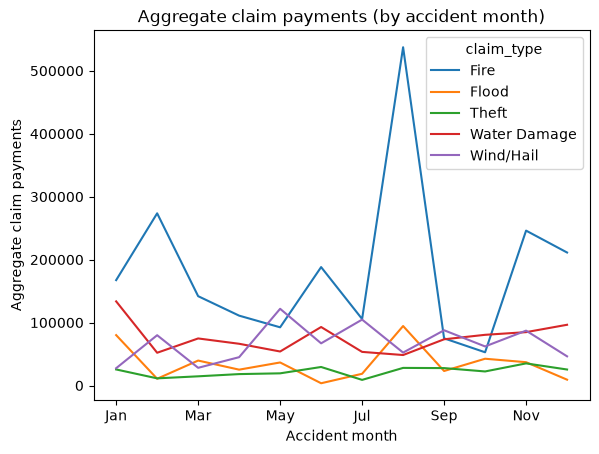

In [1098]:
pt.transpose().plot()
plt.xlabel("Accident month")
plt.ylabel("Aggregate claim payments")
plt.title("Aggregate claim payments (by accident month)")
plt.show()

Aggregate claim payments (by payment year)

In [1129]:
df_ap = pd.pivot_table(df, 
                        values="payment_amount",
                        index="claim_id", 
                        columns="payment_year", 
                        aggfunc="sum")
df_ap = df_ap.fillna(0)
df_ap['total_claim_payment'] = df_ap.sum(axis=1)
df_ap = df_ap.merge(df_c[['claim_id', 'claim_type']], 
                    on="claim_id", 
                    how="left")
df_ap = df_ap[ df_ap["total_claim_payment"] < 250000]
df_ap = df_ap.drop(columns=['total_claim_payment', 'claim_id'])
df_ap

,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0,claim_type
0,4777.43,0.00,0.00,0.00,0.0,0.00,0.0,0.00,Wind/Hail
1,0.00,0.00,0.00,0.00,5454.3,881.28,0.0,0.00,Water Damage
2,0.00,0.00,0.00,0.00,0.0,4640.37,0.0,0.00,Wind/Hail
3,0.00,0.00,0.00,0.00,0.0,0.00,0.0,6517.61,Wind/Hail
4,0.00,0.00,0.00,0.00,0.0,50.37,3894.2,2943.16,Fire
...,...,...,...,...,...,...,...,...,...
490,0.00,0.00,0.00,2750.43,0.0,0.00,0.0,0.00,Theft
491,0.00,0.00,0.00,0.00,0.0,570.62,0.0,0.00,Theft
492,0.00,0.00,4231.37,0.00,0.0,0.00,0.0,0.00,Wind/Hail
493,684.27,1433.10,434.44,0.00,0.0,0.00,0.0,0.00,Fire


In [1136]:
pt = pd.pivot_table(df_ap, index='claim_type', aggfunc='sum')
pt

,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0
claim_type,,,,,,,,
Fire,105634.59,145486.11,281506.82,297635.29,326636.00,410225.28,424722.68,210844.52
Flood,4178.53,24581.02,22428.05,34026.54,102506.28,56440.56,134848.86,41830.47
Theft,23391.83,37748.41,19093.73,19859.90,58236.97,45664.08,42025.69,19813.19
Water Damage,18750.69,78544.89,98772.83,96308.28,131558.31,163232.01,165729.06,157892.33
Wind/Hail,74864.42,57454.18,80927.48,40675.49,138011.97,164138.32,186015.12,67748.52


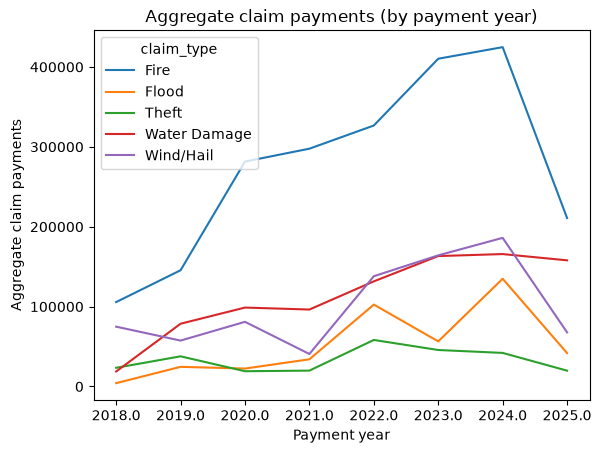

In [1137]:
pt.transpose().plot()
plt.xlabel("Payment year")
plt.ylabel("Aggregate claim payments")
plt.title("Aggregate claim payments (by payment year)")
plt.show()

### Premium change analysis

Mental note: Turn this into a **function** instead!

In [1207]:
# Input the target loss ratios here
target_loss_ratios = {'Wind/Hail' : 0.81,
              'Water Damage' : 0.87,
              'Fire' : 0.72,
              'Flood' : 0.67,
              'Theft' : 0.81}


In [1208]:
# Input the restriction errors here
reg_error = 0.05
eahii_error = 0.10

In [1213]:
df = df_prc.iloc[:, :2]
df = df.rename(columns={'2025_total_premium':'premium', 
                        '2025_total_ultimate_claims': 'ultimate_claims'})

In [1300]:
# Maps reformatting the data:

# Change data conclusions for readability
def conclusion_from_pair(pair: list) -> str:
    if pair[0] == 1:
        if pair[1] == 1:
            return 'allowed by EAHII, allowed by regulator'
        else: 
            return 'allowed by EAHII, disallowed by regulator'
    else: 
        if pair[1] == 1:
            return 'disallowed by EAHII, allowed by regulator'
        return 'disallowed by EAHII, disallowed by regulator'

# Change style
def color_entry(concl: str) -> str:
    settings = {'disallowed by EAHII, disallowed by regulator': 'background-color: #e5a9a9; color: #800000',
                'allowed by EAHII, disallowed by regulator': 'background-color: #acb3ea; color: #000080',
                'disallowed by EAHII, allowed by regulator': 'background-color: #eae7aa; color: #808000',
                'allowed by EAHII, allowed by regulator': 'background-color: #b2d6aa; color: #008000'}
    return settings[concl]

In [1306]:
rc_lb = -15   # Rate change lower bound
rc_ub = 15  # Rate change upper bound

rate_conclusions = dict()
for claim_type in df_c['claim_type'].unique().tolist():
    uc = df['ultimate_claims'].loc[claim_type]
    prem = df['premium'].loc[claim_type]
    tlr = target_loss_ratios[claim_type]
    concl_list = list()
    for r in range(rc_lb,rc_ub+1):
        concl = [0,0]
        
        # Check if the rate change falls within EAHII's restrictions
        after_adjustment_loss_ratio = uc / (prem * (1 + r/100))
        eahii_loss_ratio_lb =  (1 - eahii_error) * tlr
        eahii_loss_ratio_ub =  (1 + eahii_error) * tlr
        if eahii_loss_ratio_lb < after_adjustment_loss_ratio < eahii_loss_ratio_ub:
            concl[0] = 1
        
        # Check if the rate change falls within the regulator's restrictions
        if np.abs(r/100) <= reg_error:
            concl[1] = 1
        
        concl_list += [conclusion_from_pair(concl)]
    rate_conclusions.update({claim_type: concl_list})

df_rate_concl = pd.DataFrame(rate_conclusions,
                            columns = df_c['claim_type'].unique().tolist(),
                            index=pd.Index([f'{r}%' for r in range(rc_lb,rc_ub+1)], 
                                           name='premium_rate_change'))

df_rate_concl = df_rate_concl.style.map(color_entry)

df_rate_concl


,Wind/Hail,Water Damage,Fire,Flood,Theft
premium_rate_change,,,,,
-15%,"disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator"
-14%,"disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator"
-13%,"disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator"
-12%,"allowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator"
-11%,"allowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator"
-10%,"allowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","allowed by EAHII, disallowed by regulator"
-9%,"allowed by EAHII, disallowed by regulator","allowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","allowed by EAHII, disallowed by regulator"
-8%,"allowed by EAHII, disallowed by regulator","allowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","allowed by EAHII, disallowed by regulator"
-7%,"allowed by EAHII, disallowed by regulator","allowed by EAHII, disallowed by regulator","allowed by EAHII, disallowed by regulator","disallowed by EAHII, disallowed by regulator","allowed by EAHII, disallowed by regulator"
